# Klassificering av ansiktsuttryck med CNN och Deep Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time

import tensorflow as tf
from sklearn.metrics import accuracy_score

from utils import (
    plot_history,
    predict_classes,
    plot_confusion_matrix,
    calculate_per_class_accuracy,
    get_most_confused_pairs,
    plot_misclassified_examples,
    extract_dataset,
    predict_test_image,
    predict_custom_image,
    highlight_best_metrics
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. Förstå och undersöka datan

### 1.1 Datasetets uppbyggnad

Börjar med att undersöka hur datasetet är uppbyggt

Datasetet är uppdelat i:
- träningsdata (`train`)
- testdata (`test`)

Varje klass ligger i en egen mapp, vilket gör att bilderna automatiskt kan kopplas till rätt etikett vid inläsning.

Därefter undersöks vilka klasser som finns och om train/test innehåller samma etiketter.


In [2]:
# Huvudmapp för data
data_path = 'Data'

print('Mappar i datasetet:')
print(os.listdir(data_path))

# Sökvägar till train och test
train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')

# Hämta och sortera klassnamn
classes_train = sorted(os.listdir(train_path))
classes_test = sorted(os.listdir(test_path))

# Antal klasser (används för antal neuroner i modellens output-lager)
num_classes = len(classes_train)

print('\nAntal klasser:', num_classes)

print('\nKlasser:')
print(classes_train)

# Kontrollera att train och test matchar
print('\nSamma klasser i train och test:')
print(classes_train == classes_test)

Mappar i datasetet:
['test', 'train']

Antal klasser: 7

Klasser:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Samma klasser i train och test:
True


### 1.2 Klassfördelning i datasetet

För att förstå datans balans analyseras antalet bilder per klass i både tränings- och testdata.

Detta är viktigt eftersom klassobalans kan påverka modellens inlärning och leda till sämre resultat för minoritetsklasser.

In [3]:
# Listor och räknare för bildfördelning
data = []
total_train = 0
total_test = 0

# Räkna bilder per klass i train och test
for class_name in classes_train:

    train_count = len(os.listdir(os.path.join(train_path, class_name)))
    test_count = len(os.listdir(os.path.join(test_path, class_name)))

    total_train += train_count
    total_test += test_count

    data.append([
        class_name,
        train_count,
        test_count
    ])

# Skapa DataFrame för fördelningen
df = pd.DataFrame(
    data,
    columns=['Klass', 'Train', 'Test']
)

# Beräkna procentuell fördelning per klass
df['Train %'] = round((df['Train'] / total_train) * 100, 2)
df['Test %'] = round((df['Test'] / total_test) * 100, 2)

# Sortera efter antal träningsbilder
df_sorted = df.sort_values('Train', ascending=False)

display(df_sorted)

print(f'Totalt antal träningsbilder: {total_train}')
print(f'Totalt antal testbilder: {total_test}')

,Klass,Train,Test,Train %,Test %
3,happy,7215,1774,25.13,24.71
4,neutral,4965,1233,17.29,17.18
5,sad,4830,1247,16.82,17.37
2,fear,4097,1024,14.27,14.27
0,angry,3995,958,13.92,13.35
6,surprise,3171,831,11.05,11.58
1,disgust,436,111,1.52,1.55


Totalt antal träningsbilder: 28709
Totalt antal testbilder: 7178


### 1.3 Visualisering av klassfördelning

Stapeldiagrammet visar hur bilderna är fördelade mellan klasserna i train och test.

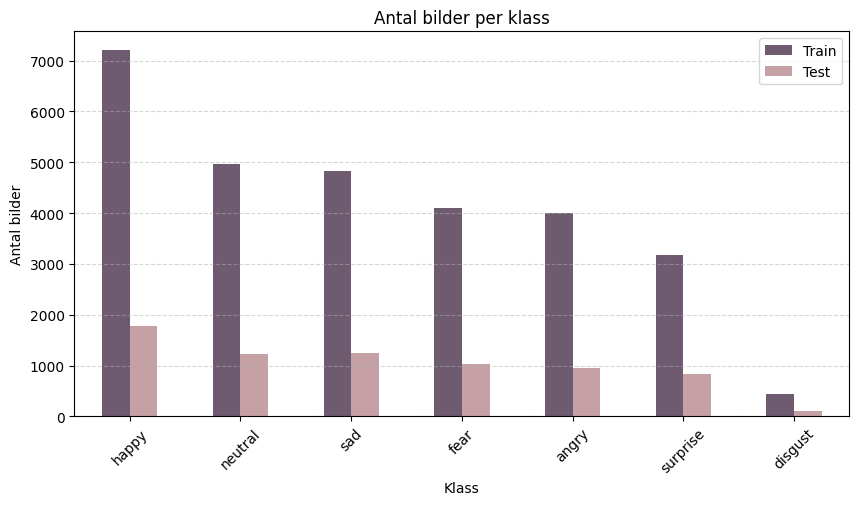

In [4]:
# Plotta fördelningen av bilder per klass
df_sorted.plot(
    x='Klass',
    y=['Train', 'Test'],
    kind='bar',
    figsize=(10, 5),
    color=['#6E5B70', '#C5A0A4']
)

plt.title('Antal bilder per klass')
plt.ylabel('Antal bilder')
plt.xticks(rotation=45)
plt.legend(['Train', 'Test'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### 1.4 Visuell kontroll av datasetet

Först visas ett exempel från en klass för att kontrollera bildens format och kvalitet.   
Därefter visas ett exempel från varje klass för att få en översikt över variationen i datasetet.

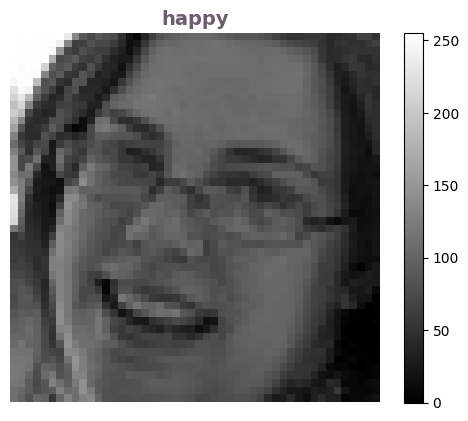

Bildens storlek: (48, 48)


In [5]:
# Klass och sökväg för en exempelbild
example_class = 'happy'
example_path = os.path.join(train_path, example_class)

# Läser in den första bilden i mappen
img_name = os.listdir(example_path)[0]
img_path = os.path.join(example_path, img_name)
img = mpimg.imread(img_path)

# Visa bilden i gråskala
plt.imshow(img, cmap='gray')

# Titel och layout
plt.title(example_class, color='#6E5B70', fontsize=14, fontweight='bold')

plt.colorbar()
plt.axis('off')
plt.show()

print('Bildens storlek:', img.shape)

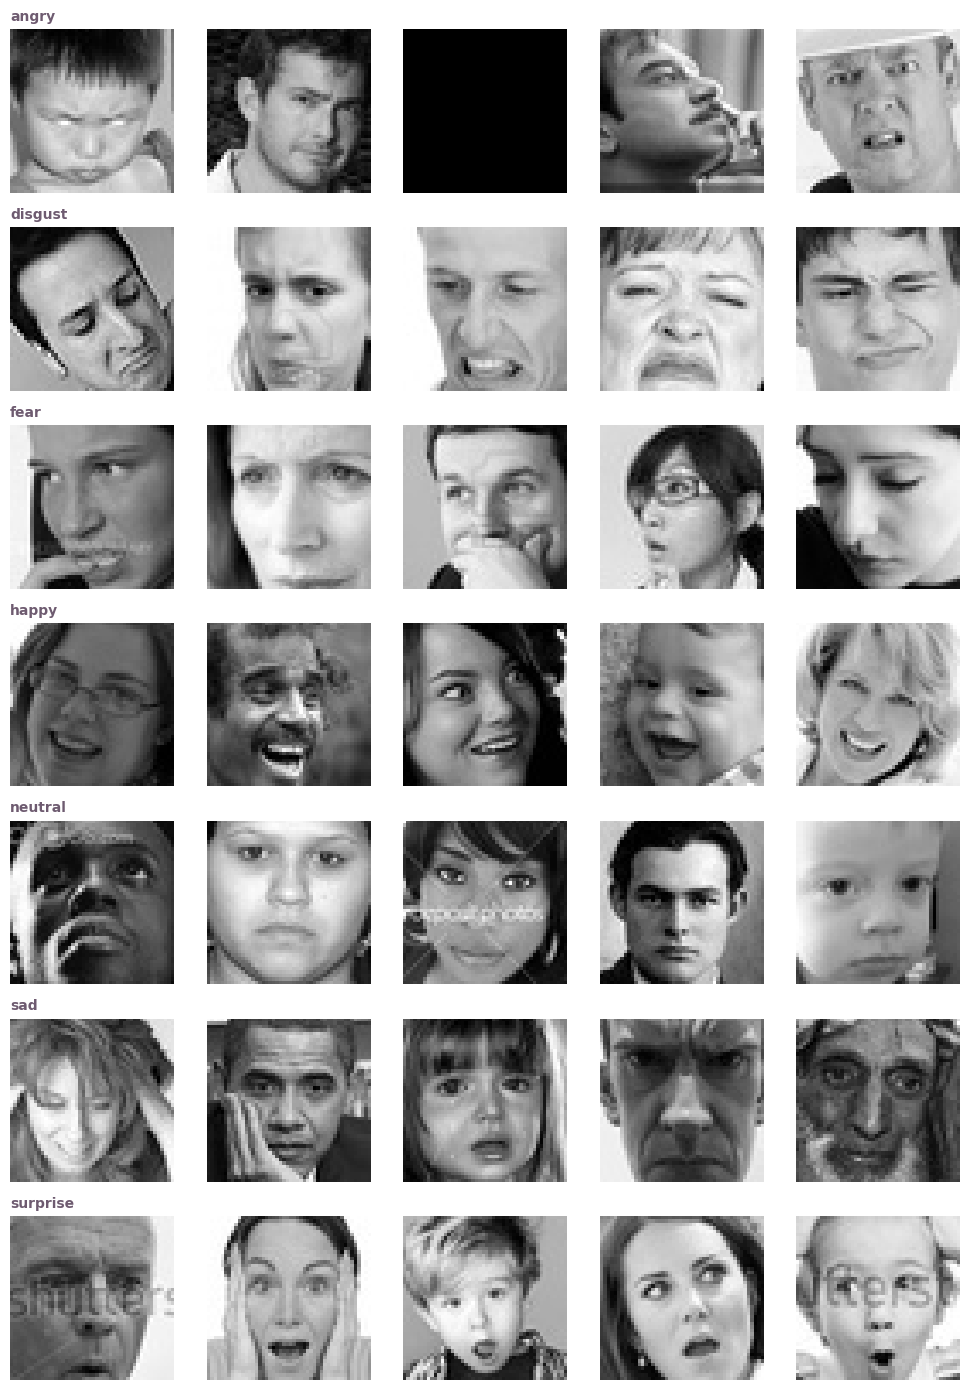

In [6]:
# Dimensioner för bildrutnätet
rows = len(classes_train)
cols = 5

plt.figure(figsize=(10, 2 * rows))

# Loopa igenom klasser och bilder
for row_idx, c in enumerate(classes_train):
    path = os.path.join(train_path, c)
    all_images = os.listdir(path)
    
    for col_idx in range(cols):
        img_name = all_images[col_idx]
        img_path = os.path.join(path, img_name)
        img = mpimg.imread(img_path)
        
        plot_index = row_idx * cols + col_idx + 1
        plt.subplot(rows, cols, plot_index)
        
        plt.imshow(img, cmap='gray')
        
        # Titel för klassen
        if col_idx == 0:
            plt.title(c, fontsize=10, loc='left', fontweight='bold', color='#6E5B70')
            
        plt.axis('off')

# Layout och visning
plt.tight_layout()
plt.show()

### 1.5 Datasetanalys

Datasetet består av bilder uppdelade i sju olika ansiktsuttryck: angry, disgust, fear, happy, neutral, sad och surprise.  
För varje klass finns både tränings- och testdata.

En analys av klassfördelningen visar att datan är tydligt obalanserad. Vissa klasser, såsom happy och neutral, innehåller betydligt fler bilder än exempelvis disgust och fear.

Denna obalans är viktig att beakta eftersom den kan påverka modellens inlärning. Modellen riskerar att bli bättre på majoritetsklasser och sämre på minoritetsklasser.

Utöver den kvantitativa analysen genomfördes även en visuell granskning av ett urval av bilder från datasetet för att bättre förstå datans karaktär.

Denna inspektion visade att bilderna varierar i både kvalitet, ljussättning och ansiktsposition. Vissa bilder är tydliga och välcentrerade, medan andra innehåller mer brus, låg kontrast eller delvis skymda ansikten.

**Slutsats och lösning**  
För att hantera detta används både modellarkitektur med regularisering samt data augmentation i senare modeller, i syfte att förbättra generalisering och minska överanpassning till dominerande klasser


## 2. Förberedelse av data

### 2.1 Inläsning och uppdelning av dataset

Datasetet läses in med `image_dataset_from_directory`, vilket automatiskt kopplar varje bild till rätt klass baserat på mappstrukturen.

Träningsdatan delas därefter upp i:
- träningsdata
- validationsdata (20 %)

Validation används under träningen för att följa modellens generalisering och upptäcka eventuell overfitting.

Samtliga bilder:
- skalas till 48x48 pixlar
- läses in som gråskalebilder
- batchas i grupper om 32


In [7]:
# Parametrar för bildladdning
img_height = 48
img_width = 48
batch_size = 32
seed = 42

# Skapa träningsdataset (80% av träningsdatan)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='training',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

# Skapa valideringsdataset (20% av träningsdatan)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset='validation',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

# Skapa testdataset utan omblandning (shuffle=False)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale',
    shuffle=False
)

# Hämta och skriv ut klassnamn
class_names = train_dataset.class_names
print('Klassnamn: ', class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Klassnamn:  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### 2.2 Normalisering och optimering av dataset

För att stabilisera träningen normaliseras pixelvärdena från intervallet 0–255 till 0–1.  
Detta gör att modellen tränas mer effektivt.

Dataseten optimeras även med prefetch(), vilket förbättrar prestandan genom att förbereda nästa batch medan modellen tränar på den nuvarande.

Slutligen kontrolleras:
- batcharnas dimensioner
- att normaliseringen fungerar korrekt

In [8]:
# Skapa lager för pixelskalning (0-255 till 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Dynamisk optimering av dataladdning
AUTOTUNE = tf.data.AUTOTUNE

# Normalisera och cachelagra träningsdatan i förväg
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

# Normalisera och cachelagra valideringsdatan i förväg
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

# Normalisera och cachelagra testdatan i förväg
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

# Kontrollera dimensioner på en batch
print('Train dataset batch shape:')
for images, labels in train_dataset.take(1):
    print(images.shape)

# Kontrollera att pixelvärdena ligger mellan 0 och 1
print('Pixel range check:')
for images, labels in train_dataset.take(1):
    print('Min:', images.numpy().min(),
          'Max:', images.numpy().max())

Train dataset batch shape:
(32, 48, 48, 1)
Pixel range check:
Min: 0.0 Max: 1.0


### 2.3 Dataset-varianter för experiment

Eftersom datasetet är relativt stort skapas flera mindre versioner av tränings- och validationsdatan.  
Syftet är att snabbare kunna testa olika modeller och minska träningstiden under utvecklingen
- Small v1: används för baseline-modell
- Small v2: används för förbättrad modell
- Full dataset: används för slutliga modeller

**Extraktion av data**  
Extraherar valideringsdata till numpy-format för att möjliggöra utvärdering (accuracy, confusion matrix etc.) .
Detta används i senare analyser där prediktioner jämförs direkt mot sanna etiketter.

**Datasetstorlek och kontroll**  
Slutligen verifieras storleken på varje dataset-variant för att säkerställa korrekt uppdelning.
Detta görs genom att räkna antal batches och multiplicera med batch-storlek.

In [9]:
# Small version 1 (baseline)
train_dataset_small_v1 = train_dataset.take(100)
validation_dataset_small_v1 = validation_dataset.take(25)

# Small version 2 (improved)
train_dataset_small_v2 = train_dataset.take(200)
validation_dataset_small_v2 = validation_dataset.take(50)

# Hela datasetet för full modell
train_dataset_full = train_dataset
validation_dataset_full = validation_dataset

# Konvertera valideringsdata till NumPy (alla dataset)
X_val_small_v1, y_val_small_v1 = extract_dataset(validation_dataset_small_v1)
X_val_small_v2, y_val_small_v2 = extract_dataset(validation_dataset_small_v2)
X_val_full, y_val_full = extract_dataset(validation_dataset_full)

print('=== ÖVERBLICK DATASET ===')

# Loopa igenom och beräkna antal bilder per dataset
for name, train_ds, val_ds in [
    ('v1', train_dataset_small_v1, validation_dataset_small_v1),
    ('v2', train_dataset_small_v2, validation_dataset_small_v2),
    ('full', train_dataset_full, validation_dataset_full)
]:
    train_batches = tf.data.experimental.cardinality(train_ds).numpy()
    val_batches = tf.data.experimental.cardinality(val_ds).numpy()

    print(f'\n{name}')
    print('Antal train bilder:      ', train_batches * batch_size)
    print('Antal validation bilder: ', val_batches * batch_size)

=== ÖVERBLICK DATASET ===

v1
Antal train bilder:       3200
Antal validation bilder:  800

v2
Antal train bilder:       6400
Antal validation bilder:  1600

full
Antal train bilder:       22976
Antal validation bilder:  5760


## 3. Test av olika modeller

I detta steg testas flera CNN-modeller med olika arkitekturer och inställningar för att undersöka hur modellernas prestanda påverkas.

Arbetet börjar med en enklare baseline-modell som sedan förbättras stegvis genom exempelvis:
- större dataset
- fler lager
- dropout
- data augmentation


Efter varje träning analyseras modellernas utveckling genom både träningshistorik och prediktioner på valideringsdatan.

Följande analyser genomförs för varje modell:
- tränings- och valideringskurvor analyseras för att identifiera inlärning och eventuell over/underfitting
- viktiga nycketal identifieras
- confusion matrix och accuracy per klass analyseras
- vanliga felklassificeringar undersöks
- felklassificerade bilder analyseras visuellt


För att kunna jämföra modellerna sparas följande nyckeltal i en gemensam lista (`results`), vilken i slutet sammanställs till en tabell:

* **`model`:** Modellens namn.
* **`best_val_loss`:** Lägsta valideringsloss under träningen. Visar hur väl modellen generaliserar.
* **`val_acc_at_best_epoch`:** Accuracy exakt vid epoken med lägst valideringsloss.
* **`val_acc`:** Slutgiltig accuracy beräknad efter att hela träningen avslutats. Används som en internkontroll samt som utgångspunkt för modellens felanalys
* **`best_epoch`:** Den epok där modellen nådde lägst `val_loss`, vilket visar när modellen var som bäst.
* **`epochs_trained`:** Totalt antal körda epoker under träningsomgången.
* **`training_time_min`:** Träningstid i minuter. Används för att väga modellens prestanda mot dess tid.

Detta gör det möjligt att jämföra modellernas styrkor, svagheter och generaliseringsförmåga samt undersöka hur olika arkitektur- och träningsval påverkar resultaten.

### 3.1 Resultatlista för modelljämförelser

En tom lista skapas för att samla resultat från samtliga modeller.
Detta gör det enklare att senare jämföra modellernas prestanda.

In [10]:
results = []

### 3.2.1 Baseline CNN

Den första modellen fungerar som en baseline för senare jämförelser.
Arkitekturen är relativt enkel och används för att skapa en grundnivå att jämföra förbättrade modeller mot.

Modellen består av:
- två convolutional-lager
- max pooling
- ett fullt kopplat dense-lager
- softmax-output för klassificering

In [11]:
# Definiera basmodellens arkitektur
base_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Kompilera modellen
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Visa modellens struktur och antal parametrar
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2.2 Träning av baseline-modellen

Baseline-modellen tränas på den mindre dataset-versionen (small_v1) för snabbare experimentering och kortare träningstid.

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2688 - loss: 1.8056 - val_accuracy: 0.2225 - val_loss: 1.8229
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3297 - loss: 1.6927 - val_accuracy: 0.3413 - val_loss: 1.6931
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3931 - loss: 1.5768 - val_accuracy: 0.3738 - val_loss: 1.6530
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4506 - loss: 1.4624 - val_accuracy: 0.3738 - val_loss: 1.6518
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4856 - loss: 1.3684 - val_accuracy: 0.3925 - val_loss: 1.6017
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5384 - loss: 1.2688 - val_accuracy: 0.3913 - val_loss: 1.5901
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5847 - loss: 1.1572 - val_accuracy: 0.3325 - val_loss: 1.7622
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6209 - loss: 1.0422 - val_accu

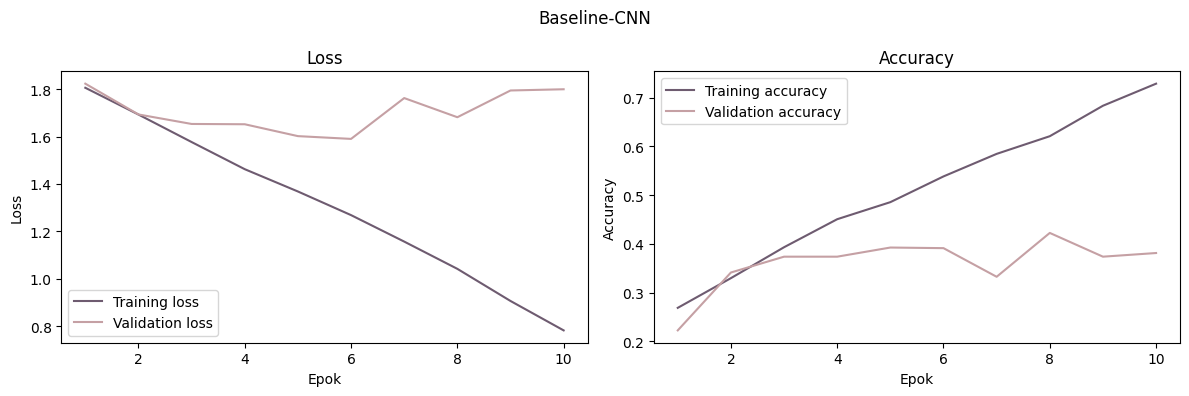

In [12]:
# Starta tidtagning
start_time = time.time()

# Träna modellen
base_history = base_model.fit(
    train_dataset_small_v1,
    validation_data=validation_dataset_small_v1,
    epochs=10
)

# Beräkna och skriv ut träningstid
training_time = time.time() - start_time
print(f'Träningstid: {training_time / 60:.2f} minuter')

# Plotta tränings- och valideringskurvor
plot_history(base_history, title='Baseline-CNN')

### 3.2.3 Observationer från träningen

Modellen förbättras tydligt under de första epokerna och träningsaccuracy fortsätter att öka över tid.

Samtidigt planar validation accuracy ut relativt tidigt medan validation loss börjar öka efter några epoker.

Detta tyder på att modellen börjar overfitta träningsdatan och får svårare att generalisera till ny data.

In [13]:
# Spara historiken i en DataFrame
base_history_df = pd.DataFrame(base_history.history)

# Hitta epoken med lägst validation loss
best_epoch = base_history_df['val_loss'].idxmin() + 1
best_val_loss = base_history_df['val_loss'].min()
best_val_accuracy = base_history_df['val_accuracy'].iloc[best_epoch - 1]

# Skriv ut resultat från träningen
print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

# Gör prediktioner och beräkna träffsäkerhet
base_y_pred, base_y_proba = predict_classes(base_model, X_val_small_v1)
base_val_acc = accuracy_score(y_val_small_v1, base_y_pred)

print(f'Baseline validation accuracy: {base_val_acc:.4f}')


Bästa validation loss vid epok: 6
Bästa validation loss: 1.5901
Validation accuracy vid den epoken: 0.3913
Baseline validation accuracy: 0.3713


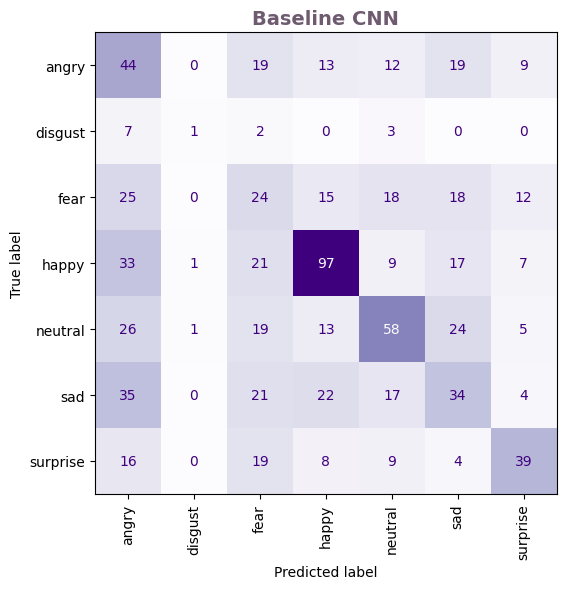

,class_id,class_name,support,correct,accuracy
1,1,disgust,13,1,0.076923
2,2,fear,112,24,0.214286
5,5,sad,133,34,0.255639
0,0,angry,116,44,0.379310
4,4,neutral,146,58,0.397260
6,6,surprise,95,39,0.410526
3,3,happy,185,97,0.524324


,true_class,predicted_class,count
25,sad,angry,35
13,happy,angry,33
19,neutral,angry,26
8,fear,angry,25
23,neutral,sad,24
27,sad,happy,22
15,happy,fear,21
26,sad,fear,21
21,neutral,fear,19
0,angry,fear,19


In [14]:
# Generera och plotta matris
base_cm = plot_confusion_matrix(
    y_val_small_v1,
    base_y_pred,
    class_names,
    title='Baseline CNN'
)

# Beräkna accuracy per klass
base_per_class = calculate_per_class_accuracy(
    base_cm,
    class_names
)
display(base_per_class)

# Hitta de klasser som modellen oftast misstar för varandra
base_confusions = get_most_confused_pairs(
    base_cm,
    class_names
)
display(base_confusions)

Antal felklassificerade exempel: 503
Andel felklassificerade: 62.88%


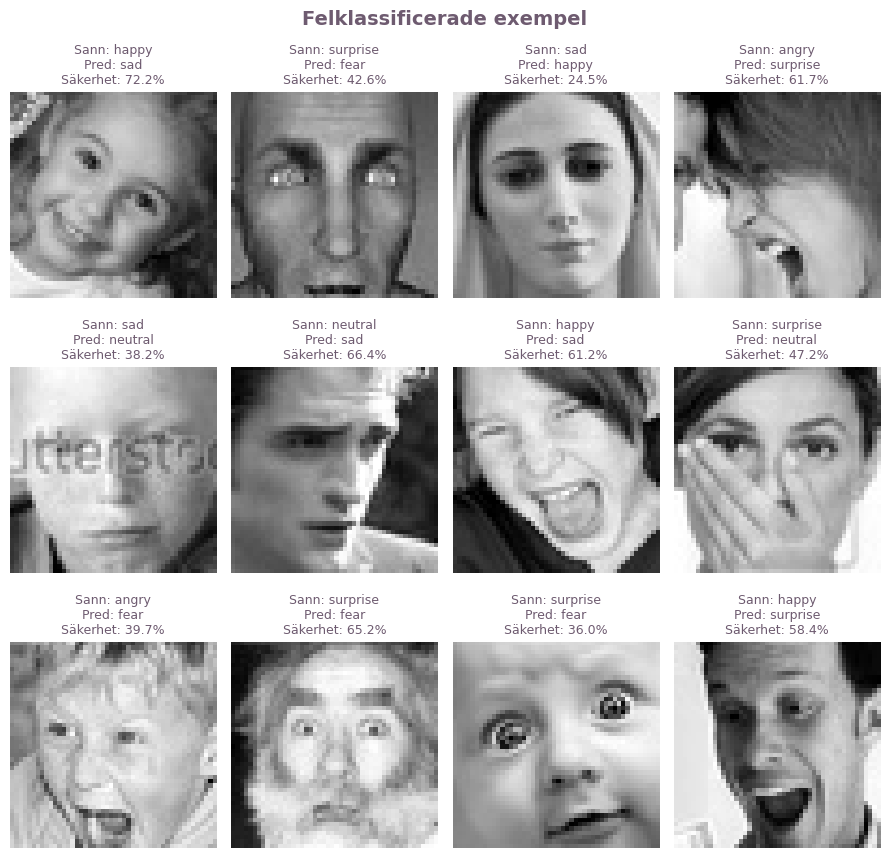

In [15]:
# Plotta exempel på bilder som modellen har felklassificerat
plot_misclassified_examples(
    X_val_small_v1,
    y_val_small_v1,
    base_y_pred,
    base_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [16]:
# Spara resultat för baseline-modellen i 'results' 
results.append({
    'model': 'baseline',
    'best_val_loss': base_history_df['val_loss'].min(),
    'val_acc_at_best_epoch': best_val_accuracy,
    'val_acc': base_val_acc,
    'best_epoch': best_epoch,
    'epochs_trained': len(base_history_df),
    'training_time_min': training_time / 60
})

# Skapa och visa sammanställningstabellen
results_df = pd.DataFrame(results)
display(results_df)

,model,best_val_loss,val_acc_at_best_epoch,val_acc,best_epoch,epochs_trained,training_time_min
0,baseline,1.590071,0.39125,0.37125,6,10,0.285379


### 3.2.4 Sammanfattning av baseline-modellen

Baseline-modellen lyckas lära sig grundläggande mönster i datan men visar tydliga tecken på overfitting.

Genomgången av felklassificeringarna och klassprestandan visar tre tydliga mönster:

- Klassobalansens påverkan: Modellen presterar bäst på de dominerande majoritetsklasserna (såsom happy), medan minoritetsklasser som har väldigt få träningsbilder (särskilt disgust) har extremt svårt att få några rätta prediktioner.

- Visuella förväxlingar: Modellen blandar ofta ihop känslouttryck som är visuellt likartade och flera av de felklassificerade exempel innehåller uttryck som även för människor kan vara svåra att tolka tydligt.

- Överdriven säkerhet: I flera fall gör modellen felaktiga prediktioner med en relativt hög säkerhet, vilket tyder på att modellen ännu inte generaliserar tillräckligt bra.


Resultatet visar samtidigt att modellen fungerar som en bra grund för vidare förbättringar


### 3.3.1 Improved CNN 

För att minska overfitting och förbättra modellens generalisering testas en mer avancerad CNN-modell 

Jämfört med baseline-modellen används:
- fler convolutional layers
- dropout
- ett större dataset

Dropout används för att minska risken att modellen anpassar sig för mycket till träningsdatan och därmed förbättra generaliseringsförmågan.

In [17]:
# Definiera Improved-modellens arkitektur
improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Kompilera modellen
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Visa modellens struktur och antal parametrar
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3.2 Träning av den förbättrade modellen

Den förbättrade modellen tränas på den större dataset-versionen (small_v2) för att ge modellen tillgång till mer träningsdata.

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.2367 - loss: 1.8366 - val_accuracy: 0.2537 - val_loss: 1.7985
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2572 - loss: 1.7901 - val_accuracy: 0.2900 - val_loss: 1.7394
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2998 - loss: 1.7239 - val_accuracy: 0.3400 - val_loss: 1.6785
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.3377 - loss: 1.6638 - val_accuracy: 0.3644 - val_loss: 1.6129
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.3784 - loss: 1.5858 - val_accuracy: 0.4031 - val_loss: 1.5641
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.4108 - loss: 1.5325 - val_accuracy: 0.4200 - val_loss: 1.5400
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.4405 - loss: 1.4600 - val_accuracy: 0.4225 - val_loss: 1.4996
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4594 - loss: 1.4087 - val_accu

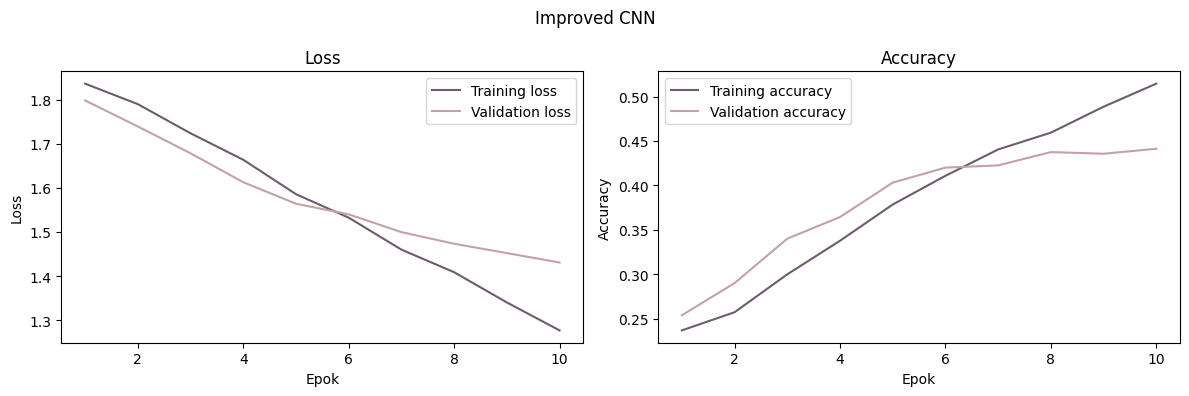

In [18]:
# Starta tidtagning
start_time = time.time()

# Träna modellen
improved_history = improved_model.fit(
    train_dataset_small_v2,
    validation_data=validation_dataset_small_v2,
    epochs=10
)

# Beräkna och skriv ut träningstid
training_time = time.time() - start_time
print(f'Träningstid: {training_time / 60:.2f} minuter')

# Plotta tränings- och valideringskurvor
plot_history(improved_history, title='Improved CNN')

### 3.3.3 Observationer från träningen

Modellen förbättras successivt under hela träningen och både tränings- och validation accuracy ökar stabilt över flera epoker.

Till skillnad från baseline-modellen syns mindre tydliga tecken på overfitting, vilket tyder på att dropout och den större datamängden bidrar till bättre generalisering.

Validation loss fortsätter dessutom att minska genom större delen av träningen, vilket indikerar att modellen fortfarande lär sig relevanta mönster i datan.

In [19]:
# Spara historiken i en DataFrame
improved_history_df = pd.DataFrame(improved_history.history)

# Hitta epoken med lägst validation loss
best_epoch = improved_history_df['val_loss'].idxmin() + 1
best_val_loss = improved_history_df['val_loss'].min()
best_val_accuracy = improved_history_df['val_accuracy'].iloc[best_epoch - 1]

# Skriv ut resultat från träningen
print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

# Gör prediktioner och beräkna träffsäkerhet
improved_y_pred, improved_y_proba = predict_classes(improved_model, X_val_small_v2)
improved_val_acc = accuracy_score(y_val_small_v2, improved_y_pred)

print(f'Improved validation accuracy: {improved_val_acc:.4f}')

Bästa validation loss vid epok: 10
Bästa validation loss: 1.4307
Validation accuracy vid den epoken: 0.4412
Improved validation accuracy: 0.4387


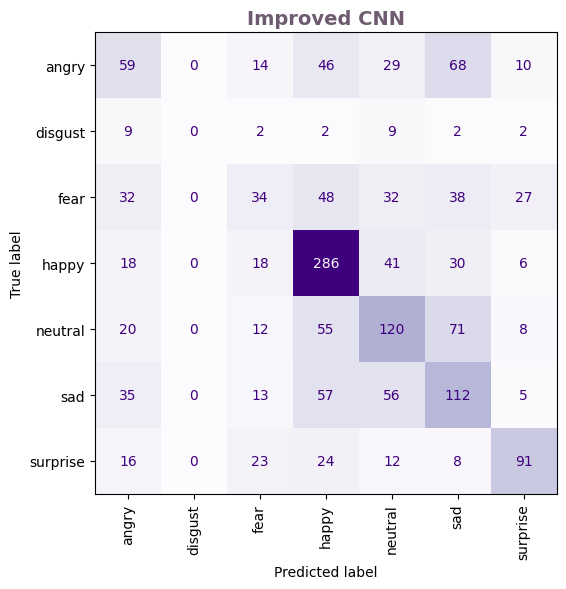

,class_id,class_name,support,correct,accuracy
1,1,disgust,26,0,0.000000
2,2,fear,211,34,0.161137
0,0,angry,226,59,0.261062
5,5,sad,278,112,0.402878
4,4,neutral,286,120,0.419580
6,6,surprise,174,91,0.522989
3,3,happy,399,286,0.716792


,true_class,predicted_class,count
24,neutral,sad,71
3,angry,sad,68
28,sad,happy,57
29,sad,neutral,56
23,neutral,happy,55
12,fear,happy,48
1,angry,happy,46
18,happy,neutral,41
14,fear,sad,38
26,sad,angry,35


In [20]:
# Generera och plotta matris
improved_cm = plot_confusion_matrix(
    y_val_small_v2,
    improved_y_pred,
    class_names,
    title='Improved CNN'
)

# Beräkna accuracy per klass
improved_per_class = calculate_per_class_accuracy(
    improved_cm,
    class_names
)
display(improved_per_class)

# Hitta de klasser som modellen oftast misstar för varandra
improved_confusions = get_most_confused_pairs(
    improved_cm,
    class_names
)
display(improved_confusions)

Antal felklassificerade exempel: 898
Andel felklassificerade: 56.12%


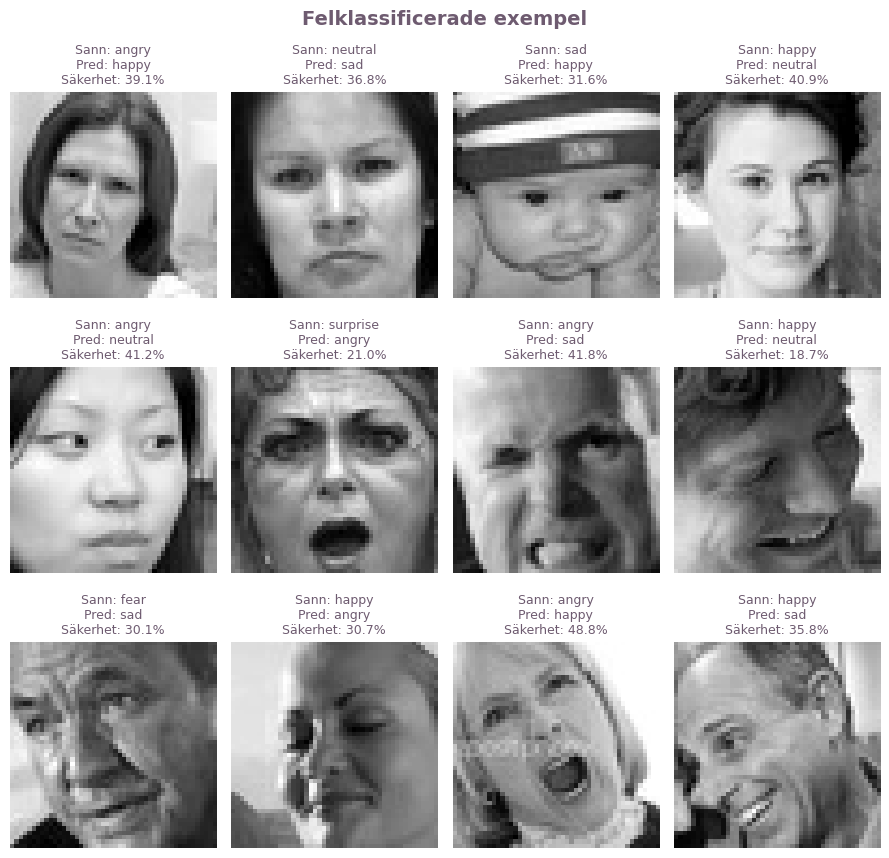

In [21]:
# Plotta exempel på bilder som modellen har felklassificerat
plot_misclassified_examples(
    X_val_small_v2,
    y_val_small_v2,
    improved_y_pred,
    improved_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [22]:
# Spara resultat för improved-modellen i 'results'
results.append({
    'model': 'improved',
    'best_val_loss': improved_history_df['val_loss'].min(),
    'val_acc_at_best_epoch': best_val_accuracy,
    'val_acc': improved_val_acc,
    'best_epoch': best_epoch,
    'epochs_trained': len(improved_history_df),
    'training_time_min': training_time / 60
})

# Skapa och visa sammanställningstabellen
results_df = pd.DataFrame(results)
display(results_df)

,model,best_val_loss,val_acc_at_best_epoch,val_acc,best_epoch,epochs_trained,training_time_min
0,baseline,1.590071,0.39125,0.37125,6,10,0.285379
1,improved,1.430669,0.44125,0.43875,10,10,1.207942


### 3.3.4 Sammanfattning av improved-modellen

Den förbättrade modellen uppnår högre validation accuracy och lägre validation loss jämfört med baseline-modellen.  
Träningskurvorna ligger närmare varandra, vilket visar att dropout och mer data har minskat overfittingen.

De viktigaste upptäckterna från analysen är:

- **Bäst på stora klasser:** Modellen har blivit mycket bättre på de klasser som har många bilder (som happy och surprise).

- **Svårt för små klasser:** De klasser som har väldigt få bilder (disgust och fear) är fortfarande jättesvåra för modellen att gissa rätt på.

- **Gissar ofta på "neutral":** Det absolut vanligaste felet är att modellen gissar på neutral när den egentligen ser en ledsen (sad) eller arg (angry) person.

- **Tar längre tid:** Eftersom modellen har fler lager och mer data tar den också längre tid att träna.

**Slutsats:** Modellen har blivit mycket bättre på att hantera nya bilder, men klassobalansen är fortfarande ett problem.

### 3.4.1 Improved 2 CNN - större datamängd och Early Stopping

I denna version behålls samma grundarkitektur som i föregående modell, men modellen tränas nu på hela träningsdatan istället för ett mindre subset.

Målet är att undersöka om mer träningsdata kan förbättra modellens generaliseringsförmåga och ge stabilare resultat.

För att minska risken för overfitting används även `EarlyStopping`, vilket avbryter träningen när validation loss slutar förbättras och återställer modellens bästa vikter.

En möjlig förbättring hade varit att testa en djupare modellarkitektur, men eftersom modellen redan visar tillräcklig kapacitet ligger fokus här istället på datamängd och regularisering.

Jämfört med tidigare modeller används:
- hela träningsdatasetet
- EarlyStopping
- samma CNN-arkitektur med dropout

In [23]:
# Definiera improved2-modellens arkitektur
improved2_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Kompilera modellen
improved2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Visa modellens struktur och antal parametrar
improved2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### 3.4.2 Träning av Improved 2-modellen

Modellen tränas på hela träningsdatan med maximalt 20 epoker och earlystopping

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.2789 - loss: 1.7675 - val_accuracy: 0.3745 - val_loss: 1.6140
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3716 - loss: 1.6006 - val_accuracy: 0.4313 - val_loss: 1.4668
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.4246 - loss: 1.4778 - val_accuracy: 0.4679 - val_loss: 1.3803
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.4627 - loss: 1.3909 - val_accuracy: 0.4942 - val_loss: 1.3233
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.4878 - loss: 1.3299 - val_accuracy: 0.5118 - val_loss: 1.2770
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5074 - loss: 1.2825 - val_accuracy: 0.5231 - val_loss: 1.2507
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.5316 - loss: 1.2261 - val_accuracy: 0.5252 - val_loss: 1.2336
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.5407 - loss: 1.1911 - 

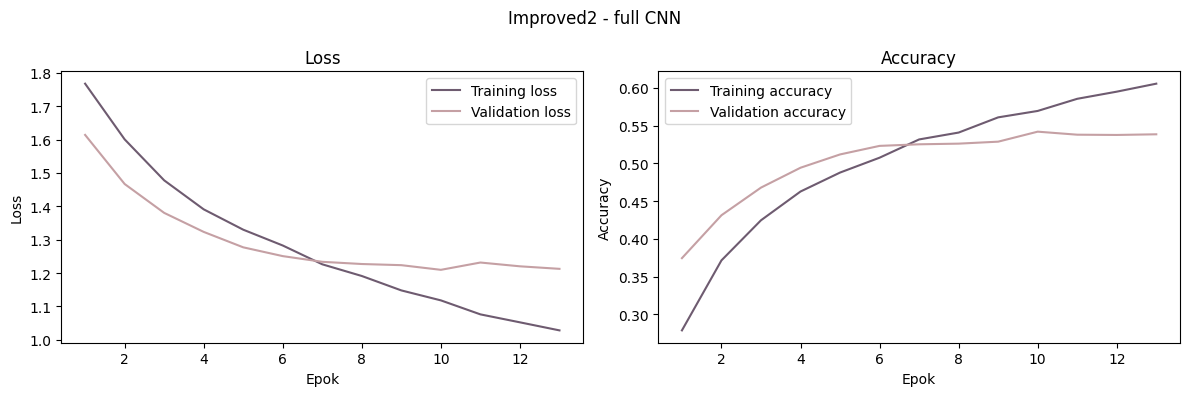

In [25]:
# Starta tidtagning
start_time = time.time()

# Träna modellen
improved2_history = improved2_model.fit(
    train_dataset_full,
    validation_data=validation_dataset_full,
    epochs=20,
    callbacks=[early_stop]
)

# Beräkna och skriv ut träningstid
training_time = time.time() - start_time
print(f'Träningstid: {training_time / 60:.2f} minuter')

# Plotta tränings- och valideringskurvor
plot_history(improved2_history, title='Improved2 - full CNN')

### 3.4.3 Observationer från träningen

Modellen förbättras stabilt under större delen av träningen och både tränings- och validation accuracy ökar successivt över flera epoker.

Validation loss fortsätter dessutom att minska under lång tid, vilket tyder på att den större datamängden hjälper modellen att generalisera bättre än tidigare modeller.

Mot slutet av träningen börjar förbättringarna plana ut samtidigt som skillnaden mellan tränings- och validation accuracy ökar något. Detta indikerar att modellen börjar närma sig overfitting, men att EarlyStopping hjälper till att begränsa problemet.

Överlag visar träningskurvorna en stabilare och mer robust inlärning jämfört med tidigare modeller.

In [26]:
# Spara historiken i en DataFrame
improved2_history_df = pd.DataFrame(improved2_history.history)

# Hitta epoken med lägst validation loss
best_epoch = improved2_history_df['val_loss'].idxmin() + 1
best_val_loss = improved2_history_df['val_loss'].min()
best_val_accuracy = improved2_history_df['val_accuracy'].iloc[best_epoch - 1]

# Skriv ut resultat från träningen
print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

# Gör prediktioner och beräkna träffsäkerhet
improved2_y_pred, improved2_y_proba = predict_classes(improved2_model, X_val_full)
improved2_val_acc = accuracy_score(y_val_full, improved2_y_pred)

print(f'Improved2 validation accuracy: {improved2_val_acc:.4f}')

Bästa validation loss vid epok: 10
Bästa validation loss: 1.2096
Validation accuracy vid den epoken: 0.5419
Improved2 validation accuracy: 0.5419


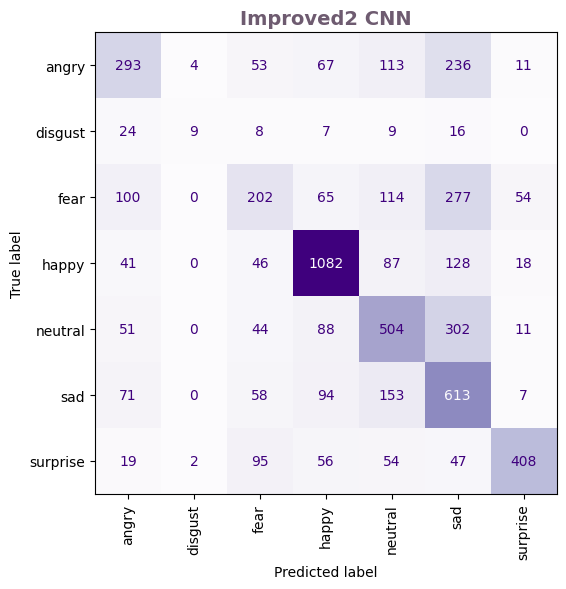

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,9,0.123288
2,2,fear,812,202,0.248768
0,0,angry,777,293,0.377091
4,4,neutral,1000,504,0.504000
6,6,surprise,681,408,0.599119
5,5,sad,996,613,0.615462
3,3,happy,1402,1082,0.771755


,true_class,predicted_class,count
24,neutral,sad,302
14,fear,sad,277
4,angry,sad,236
29,sad,neutral,153
19,happy,sad,128
13,fear,neutral,114
3,angry,neutral,113
11,fear,angry,100
33,surprise,fear,95
28,sad,happy,94


In [27]:
# Generera och plotta matris
improved2_cm = plot_confusion_matrix(
    y_val_full,
    improved2_y_pred,
    class_names,
    title='Improved2 CNN'
)

# Beräkna accuracy per klass
improved2_per_class = calculate_per_class_accuracy(
    improved2_cm,
    class_names
)
display(improved2_per_class)

# Hitta de klasser som modellen oftast misstar för varandra
improved2_confusions = get_most_confused_pairs(
    improved2_cm,
    class_names
)
display(improved2_confusions)

Antal felklassificerade exempel: 2630
Andel felklassificerade: 45.81%


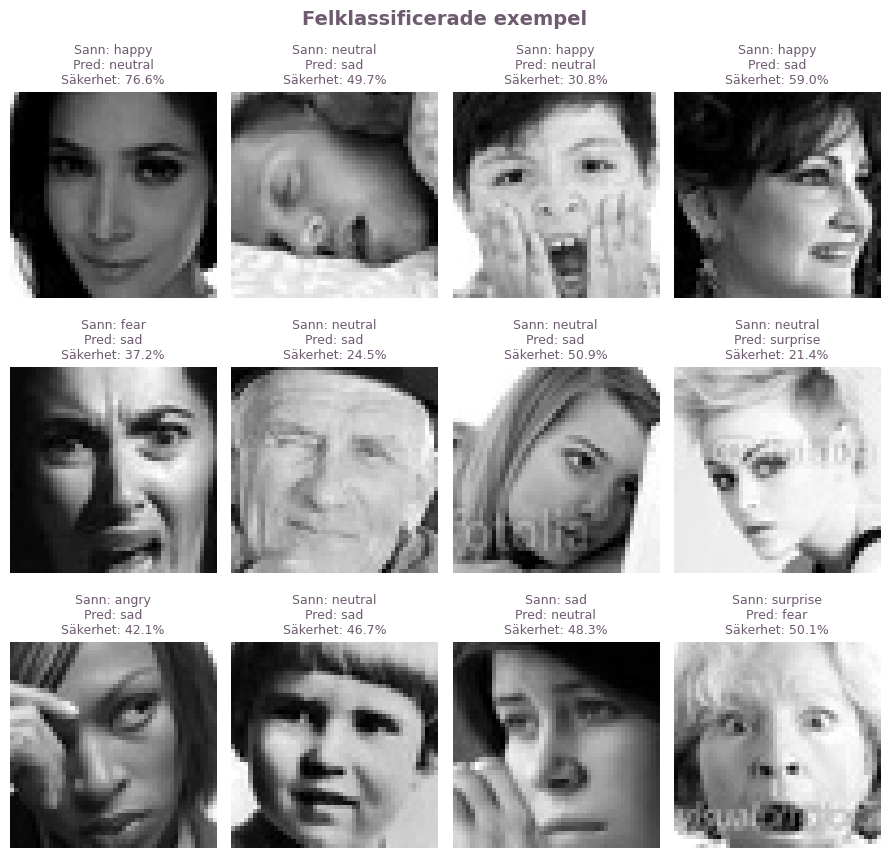

In [28]:
# Plotta exempel på bilder som modellen har felklassificerat
plot_misclassified_examples(
    X_val_full,
    y_val_full,
    improved2_y_pred,
    improved2_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [29]:
# Spara resultat för improved2-modellen i 'results'
results.append({
    'model': 'improved2',
    'best_val_loss': improved2_history_df['val_loss'].min(),
    'val_acc_at_best_epoch': best_val_accuracy,
    'val_acc': improved2_val_acc,
    'best_epoch': best_epoch,
    'epochs_trained': len(improved2_history_df),
    'training_time_min': training_time / 60
})

# Skapa och visa sammanställningstabellen
results_df = pd.DataFrame(results)
display(results_df)

,model,best_val_loss,val_acc_at_best_epoch,val_acc,best_epoch,epochs_trained,training_time_min
0,baseline,1.590071,0.391250,0.371250,6,10,0.285379
1,improved,1.430669,0.441250,0.438750,10,10,1.207942
2,improved2,1.209575,0.541892,0.541892,10,13,6.500515


### 3.4.4 Sammanfattning av Improved 2-modellen

3.4.4 Sammanfattning av Improved 2-modellen
Genom att använda hela datasetet och Early Stopping har modellen nått sina bästa resultat hittills. Träningskurvorna visar en mycket stabilare inlärning, och Early Stopping avbröt träningen i rätt tid (vid epok 15) för att förhindra att modellen började overfitta.

De viktigaste upptäckterna från analysen är:

- **Stor nytta av mer data:** Modellen blev mycket säkrare och bättre på nästan alla klasser när den fick se alla bilder. Happy och surprise är fortfarande modellens starkaste klasser.

- **Framsteg för små klasser:** Den minsta klassen (disgust) lyckas nu få en del rätt, även om den och fear fortfarande är de svåraste klasserna.

- **Nya felmönster:** Modellen blandar fortfarande ihop sad och neutral, men ett nytt vanligt fel är att den också blandar ihop fear och sad.

- **Längre träningstid:** Eftersom modellen tränas på hela datasetet tog träningen betydligt längre tid (nästan 7 minuter), vilket visar att mer data kräver mer datorkraft.

**Slutsats:** Att skala upp datamängden var det som gav störst effekt på modellens prestanda. Modellen är nu mycket mer robust, men har fortfarande svårt med vissa visuellt lika ansiktsuttryck.

### 3.5.1 Final CNN - test av data augmentation

I denna modell testas data augmentation för att undersöka om modellen kan generalisera bättre genom att tränas på varierade versioner av bilderna.

Augmentation används endast på träningsdatan och består av:
- horisontell spegling
- mindre rotationer
- mindre zoomförändringar

Tanken är att modellen ska bli mindre känslig för små variationer i ansikten och därmed prestera bättre på ny data.
Övrig arkitektur behålls från föregående modell för att isolera effekten av data augmentation.



In [30]:
# Definiera lager för data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=42),
    tf.keras.layers.RandomRotation(0.1, seed=42),
    tf.keras.layers.RandomZoom(0.1, seed=42),
])

In [31]:
# Definiera final-modellens arkitektur
final_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Kompilera modellen
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Visa modellens struktur och antal parametrar
final_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

### 3.5.2 Träning av finalmodellen

Finalmodellen tränades initialt med samma inställningar som föregående modell, men med dataaugmentation aktiverad.  

Under den första träningen avbröts modellen redan efter 3 epoker på grund av early stopping, vilket tydde på att träningen stoppades för tidigt. För att ge modellen mer tid att lära sig ökades därför `patience` från 3 till 5.

Eftersom dataaugmentation gör träningsdatan mer varierad och svårare att lära sig från, skedde inlärningen långsammare än tidigare. Antalet epoker ökades därför till 40 för att modellen skulle få tillräckligt med tid att träna.

In [32]:
# Definiera callback för early stopping med återställning av bästa vikter
early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Epoch 1/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.2560 - loss: 1.8001 - val_accuracy: 0.2923 - val_loss: 1.7259
Epoch 2/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.2874 - loss: 1.7431 - val_accuracy: 0.3229 - val_loss: 1.6730
Epoch 3/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.3253 - loss: 1.6834 - val_accuracy: 0.3971 - val_loss: 1.5605
Epoch 4/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.3606 - loss: 1.6195 - val_accuracy: 0.4168 - val_loss: 1.5103
Epoch 5/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3931 - loss: 1.5588 - val_accuracy: 0.4372 - val_loss: 1.4626
Epoch 6/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4121 - loss: 1.5129 - val_accuracy: 0.4625 - val_loss: 1.3967
Epoch 7/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4284 - loss: 1.4796 - val_accuracy: 0.4757 - val_loss: 1.3617
Epoch 8/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4384 - loss: 1.4460 - 

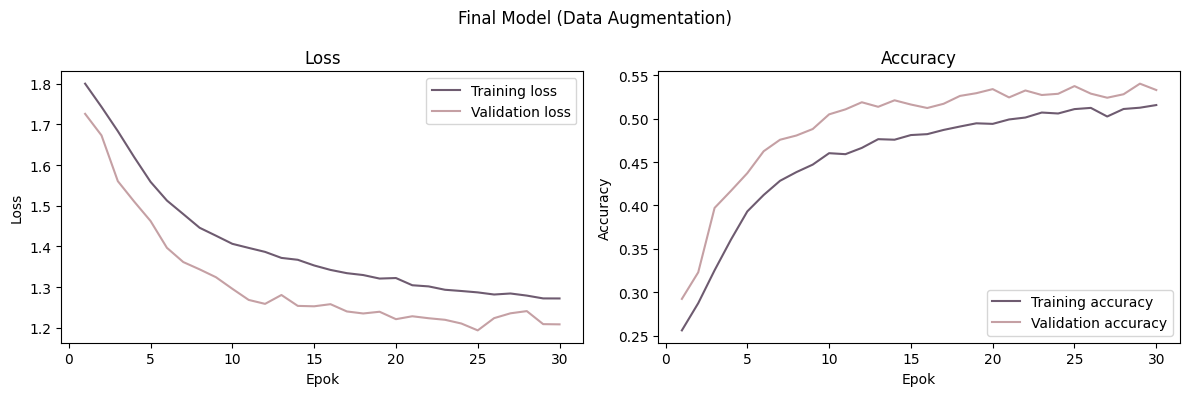

In [33]:
# Starta tidtagning
start_time = time.time()

# Träna modellen
final_history = final_model.fit(
    train_dataset_full,
    validation_data=validation_dataset_full,
    epochs=40,
    callbacks=[early_stop_2]
)

# Beräkna och skriv ut träningstid
training_time = time.time() - start_time
print(f'Träningstid: {training_time / 60:.2f} minuter')

# Plotta tränings- och valideringskurvor
plot_history(final_history, title='Final Model (Data Augmentation)')

### 3.5.3 Observationer från träningen

Observationer från träningen
Träningen tar längre tid: När data augmentation används blir varje epok svårare för modellen. Det gjorde att träningen tog betydligt längre tid och krävde att jag höjde patience och max antal epoker för att modellen inte skulle avbrytas för tidigt.

Valideringen ser bättre ut än träningen: I träningskurvorna kan vi se och tolka att validerings-accuracy ligger över tränings-accuracy, och validerings-loss ligger under tränings-loss. Detta beror på att träningsbilderna hela tiden förändras och blir svårare att lära sig, medan valideringsbilderna är stabila och "rena", vilket gör dem lättare för modellen under själva träningen.

In [34]:
# Spara historiken i en DataFrame
final_history_df = pd.DataFrame(final_history.history)

# Hitta epoken med lägst validation loss
best_epoch = final_history_df['val_loss'].idxmin() + 1
best_val_loss = final_history_df['val_loss'].min()
best_val_accuracy = final_history_df['val_accuracy'].iloc[best_epoch - 1]

# Skriv ut resultat från träningen
print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

# Gör prediktioner och beräkna träffsäkerhet
final_y_pred, final_y_proba = predict_classes(final_model, X_val_full)
final_val_acc = accuracy_score(y_val_full, final_y_pred)

print(f'Final validation accuracy: {final_val_acc:.4f}')

Bästa validation loss vid epok: 25
Bästa validation loss: 1.1938
Validation accuracy vid den epoken: 0.5375
Final validation accuracy: 0.5375


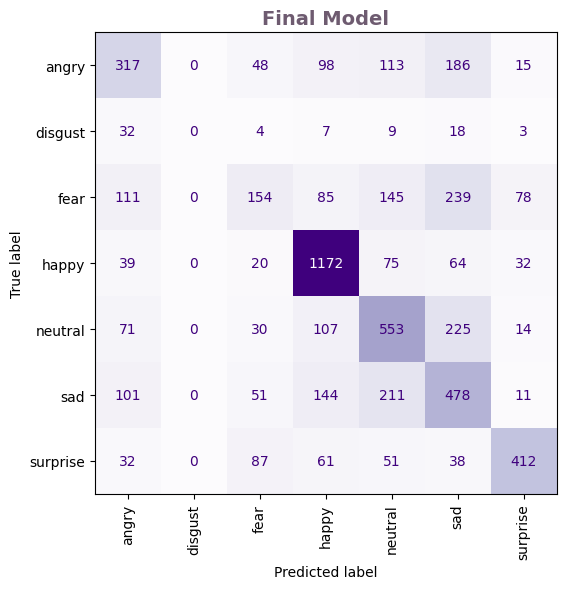

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,0,0.000000
2,2,fear,812,154,0.189655
0,0,angry,777,317,0.407979
5,5,sad,996,478,0.479920
4,4,neutral,1000,553,0.553000
6,6,surprise,681,412,0.604993
3,3,happy,1402,1172,0.835949


,true_class,predicted_class,count
14,fear,sad,239
24,neutral,sad,225
29,sad,neutral,211
3,angry,sad,186
13,fear,neutral,145
28,sad,happy,144
2,angry,neutral,113
11,fear,angry,111
23,neutral,happy,107
26,sad,angry,101


In [35]:
# Generera och plotta matris
final_cm = plot_confusion_matrix(
    y_val_full,
    final_y_pred,
    class_names,
    title='Final Model'
)

# Beräkna accuracy per klass
final_per_class = calculate_per_class_accuracy(
    final_cm,
    class_names
)
display(final_per_class)

# Hitta de klasser som modellen oftast misstar för varandra
final_confusions = get_most_confused_pairs(
    final_cm,
    class_names
)
display(final_confusions)


Antal felklassificerade exempel: 2655
Andel felklassificerade: 46.25%


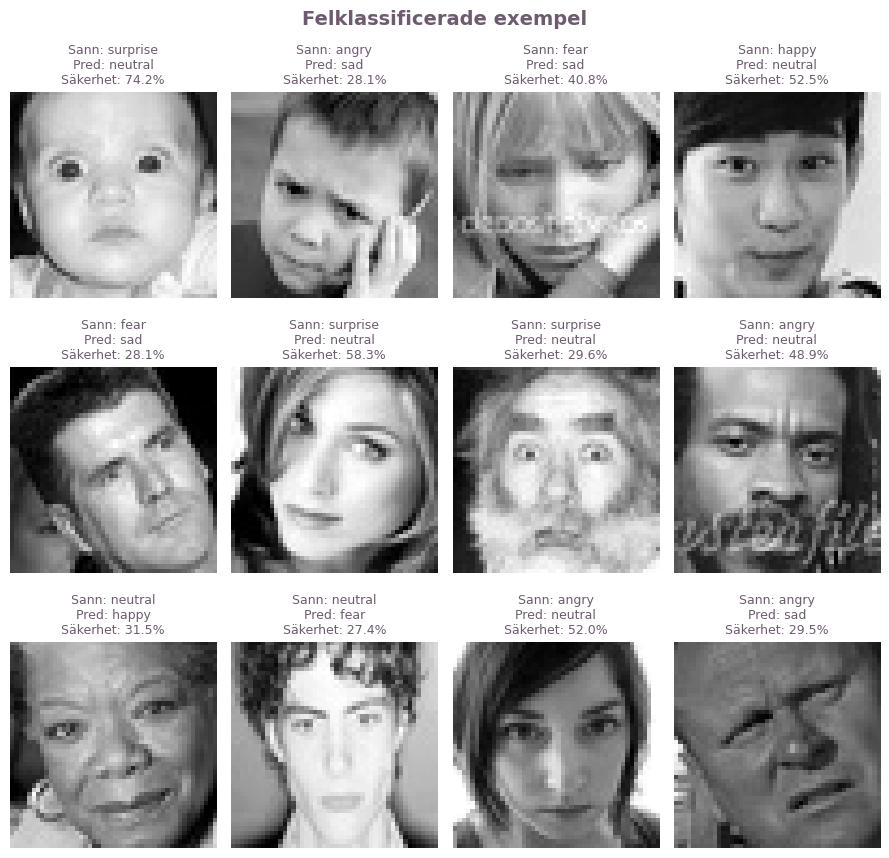

In [36]:
# Plotta exempel på bilder som modellen har felklassificerat
plot_misclassified_examples(
    X_val_full,
    y_val_full,
    final_y_pred,
    final_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [37]:
# Spara resultat för final-modellen i 'results'
results.append({
    'model': 'final (augmentation)',
    'best_val_loss': final_history_df['val_loss'].min(),
    'val_acc_at_best_epoch': best_val_accuracy,
    'val_acc': final_val_acc,
    'best_epoch': best_epoch,
    'epochs_trained': len(final_history_df),
    'training_time_min': training_time / 60
})

# Skapa och visa sammanställningstabellen
results_df = pd.DataFrame(results)
display(results_df)

,model,best_val_loss,val_acc_at_best_epoch,val_acc,best_epoch,epochs_trained,training_time_min
0,baseline,1.590071,0.391250,0.371250,6,10,0.285379
1,improved,1.430669,0.441250,0.438750,10,10,1.207942
2,improved2,1.209575,0.541892,0.541892,10,13,6.500515
3,final (augmentation),1.193823,0.537537,0.537537,25,30,16.490443


### 3.5.4 Sammanfattning av finalmodellen
Finalmodellen med data augmentation nådde inte riktigt lika bra resultat på valideringsdatan som vår förra modell (Improved 2).

De viktigaste upptäckterna från analysen är:

- **Lågupplösta bilder blir för svåra:** Eftersom bilderna i datasetet redan är väldigt små och lågupplösta (48x48 pixlar), gör funktioner som zoom och rotation att bilderna blir ännu mer suddiga. Istället för att hjälpa modellen gör detta att viktig information går förlorad och träningen blir för svår.

- **Bäst på stora klasser:** Modellen är fortfarande bäst på de klasser som har flest bilder (som happy och surprise), medan de minsta klasserna fortfarande är mycket svåra.

- **Vanliga felmönster:** Modellen blandar fortfarande ofta ihop känslor som liknar varandra rent visuellt, och tenderar att gissa på de större klasserna när den är osäker.

**Slutsats:** Data augmentation gjorde träningen svårare och tog mer tid, utan att ge bättre resultat på valideringsdatan. Det visar att data augmentation inte alltid är rätt verktyg, särskilt inte när bilderna redan har en väldigt låg upplösning från början.3



### 3.6 Sutlig jämförelsetabell 

In [38]:
# Sortera tabellen så att modellen med högst validation accuracy hamnar överst
results_sorted = results_df.sort_values(by='val_acc', ascending=False).reset_index(drop=True)

# Visa den färdiga tabellen med formatering och styling
print('=== RANGORDNING AV MODELLER (BÄST ÖVERST) ===')
results_sorted.style.apply(highlight_best_metrics, axis=None).format({
    'best_val_loss': '{:.4f}',
    'val_acc_at_best_epoch': '{:.4f}',
    'val_acc': '{:.4f}',
    'training_time_min': '{:.2f} min'
})

=== RANGORDNING AV MODELLER (BÄST ÖVERST) ===


,model,best_val_loss,val_acc_at_best_epoch,val_acc,best_epoch,epochs_trained,training_time_min
0,improved2,1.2096,0.5419,0.5419,10,13,6.50 min
1,final (augmentation),1.1938,0.5375,0.5375,25,30,16.49 min
2,improved,1.4307,0.4412,0.4387,10,10,1.21 min
3,baseline,1.5901,0.3913,0.3713,6,10,0.29 min


### 3.7 Slutgiltig jämförelse och val av bästa modell
Efter att ha testat och utvärderat fyra olika modeller i en tabell, kan vi se tydliga mönster i hur de har presterat:

Baseline CNN: Tränades snabbt på en liten del av datan. Den visade tydliga tecken på overfitting eftersom den blev jättebra på träningsdatan men stannade av helt på valideringsdatan. Den hade också 0 % rätt på den minsta klassen (disgust).

Improved CNN: Genom att lägga till fler lager och dropout lyckades vi minska överanpassningen. Precisionen ökade direkt och modellen blev mycket bättre på att hantera nya bilder.

Improved 2 CNN (Bästa modell): Genom att använda hela datasetet och Early Stopping fick vi modellens absolut bästa resultat. Träningskurvorna blev stabila och modellen lyckades för första gången få en del rätt även på de svåraste minoritetsklasserna. Early Stopping avbröt träningen i perfekt tid för att förhindra overfitting.

Final Model (Data Augmentation): Att förändra träningsbilderna genom zoom och rotation gjorde tyvärr modellen sämre. Eftersom bilderna redan är så små (48x48 pixlar) förstörde förvrängningarna den lilla information som fanns, vilket gjorde träningen för svår och långsam.

**Motivering av val av bästa modell**
Jag väljer Improved 2 CNN som min slutgiltiga modell för att göra prediktioner och utvärdera på testdatan.
Motivering:
Modellen har den högsta accuracyn och den lägsta lossen på valideringsdatan av alla modeller.   
Genom att träna på hela datasetet med dropout och Early Stopping har den fått den bästa balansen mellan att pricka rätt på de flera av de stora klasserna och även klara några av de mindre.


## 4. Spara och ladda bästa modell
Här sparas den bästa modellen (Improved 2) till en fil.   
Detta görs för att vi ska kunna ladda in exakt rätt vikter och använda modellen i framtiden utan att behöva träna om den.

In [39]:
# Spara den bästa modellen till en fil
best_model = improved2_model
best_model.save('best_emotion_model.keras')
print('Modellen sparades!')

# Ladda den sparade modellen för att verifiera att det fungerar
loaded_model = tf.keras.models.load_model('best_emotion_model.keras')
print('Modellen laddades!')

Modellen sparades!
Modellen laddades!


## 5. Utvärdering på testdata
Modellen utvärderas nu på testdatasetet. Denna data har modellen aldrig sett tidigare, vilket ger ett helt ärligt svar på hur bra modellen fungerar i verkligheten.

## 5. Utvärdering på testdata
Modellen utvärderas nu på testdatasetet. Denna data har modellen aldrig sett tidigare, vilket ger ett helt ärligt svar på hur väl modellen generaliserar till ny data i verkligheten.

Utvärderingen görs i två steg:
1. **Direkt utvärdering:** Först används Keras inbyggda funktion `.evaluate()` för att snabbt få fram testsetets slutgiltiga `loss` och `accuracy`.
2. **Extraktion för djupanalys:** Därefter extraheras bilderna manuellt för att generera unika prediktioner. Detta görs dels som en extra kontroll för att verifiera accuracy, men framför allt för att spara ner prediktionerna (`test_y_pred`) så att jag kan analysera felklasificeringar och rita ut en confusion matrix i nästa steg.

In [40]:
# Utvärdera modellen på testdatasetet
test_loss, test_accuracy = loaded_model.evaluate(test_dataset)

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

# Extrahera dataset
X_test, y_test = extract_dataset(test_dataset)

# Gör prediktioner och beräkna accuracy
test_y_pred, test_y_proba = predict_classes(loaded_model, X_test)
test_acc = accuracy_score(y_test, test_y_pred)

print(f'Test accuracy: {test_acc:.4f}')

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5408 - loss: 1.2085
Test loss: 1.2085
Test accuracy: 0.5408
Test accuracy: 0.5408


### 5.1 Felanalys på testdata
För att förstå modellens styrkor och svagheter på ny data analyserar vi en confusion matrix och tittar på exempel där modellen har gissat fel.

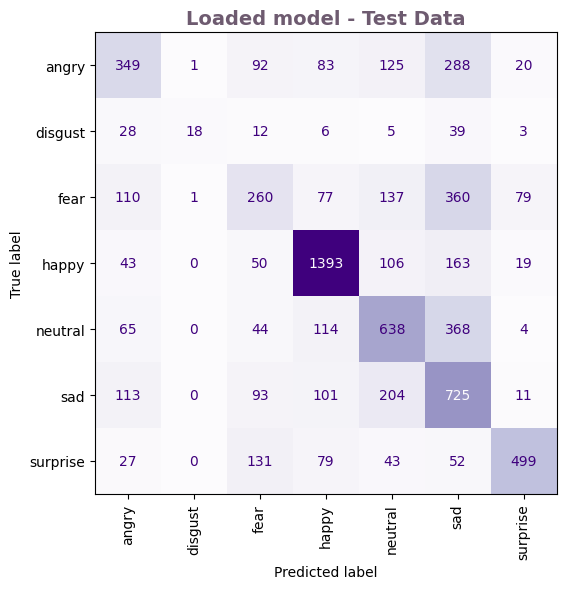

,class_id,class_name,support,correct,accuracy
1,1,disgust,111,18,0.162162
2,2,fear,1024,260,0.253906
0,0,angry,958,349,0.364301
4,4,neutral,1233,638,0.517437
5,5,sad,1247,725,0.581395
6,6,surprise,831,499,0.600481
3,3,happy,1774,1393,0.785231


,true_class,predicted_class,count
26,neutral,sad,368
16,fear,sad,360
4,angry,sad,288
31,sad,neutral,204
21,happy,sad,163
15,fear,neutral,137
34,surprise,fear,131
3,angry,neutral,125
25,neutral,happy,114
28,sad,angry,113


In [41]:
# Generera och plotta matris
test_cm = plot_confusion_matrix(
    y_test,
    test_y_pred,
    class_names,
    title='Loaded model - Test Data'
)

# Beräkna accuracy per klass
test_per_class = calculate_per_class_accuracy(
    test_cm,
    class_names
)
display(test_per_class)

# Hitta de klasser som modellen oftast misstar för varandra
test_confusions = get_most_confused_pairs(
    test_cm,
    class_names
)
display(test_confusions)

Antal felklassificerade exempel: 3296
Andel felklassificerade: 45.92%


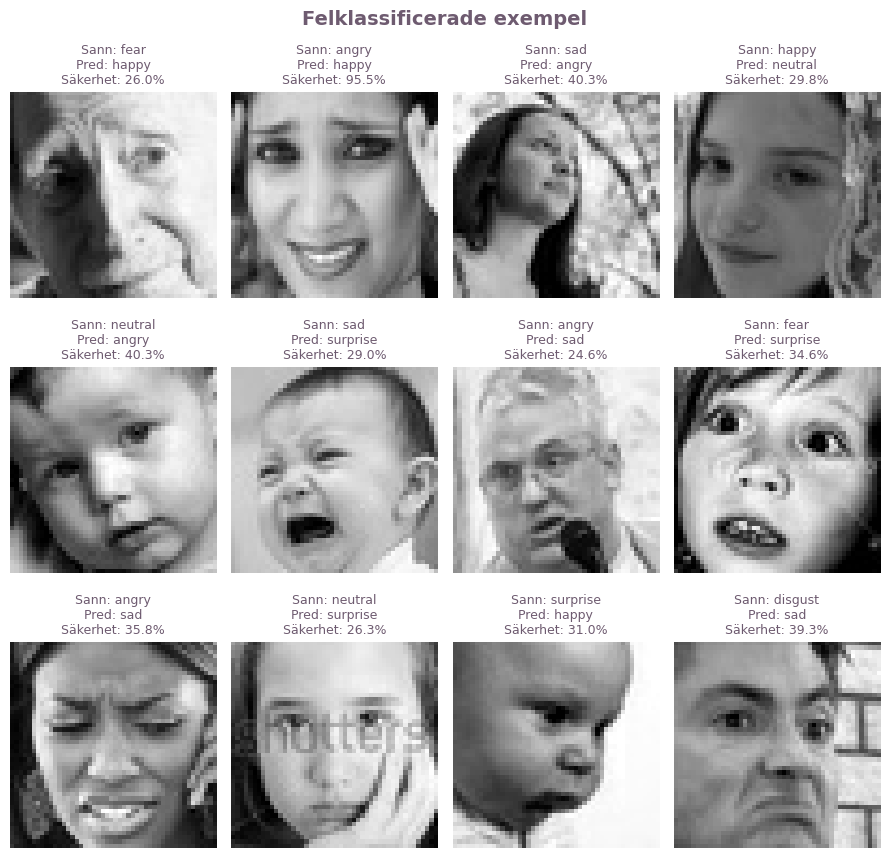

In [42]:
# Plotta exempel på bilder som modellen har felklassificerat
plot_misclassified_examples(
    X_test,
    y_test,
    test_y_pred,
    test_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

## 5.2 Interaktivt sluttest
Här kan vi välja ut en specifik bild från testdatan med hjälp av dess index. Detta gör det möjligt att visuellt granska exakt hur modellen fördelar sina sannolikheter på enskilda ansikten, och se om modellen har hög eller låg säkerhet i sina gissningar.


In [43]:
print(f"För att välj en bild sätt index till en siffra mellan 0 och {len(X_test)-1}")

För att välj en bild sätt index till en siffra mellan 0 och 7177


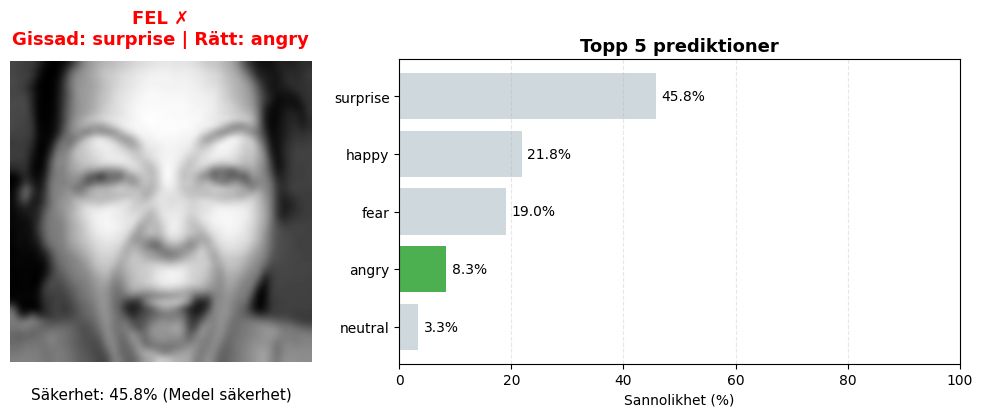

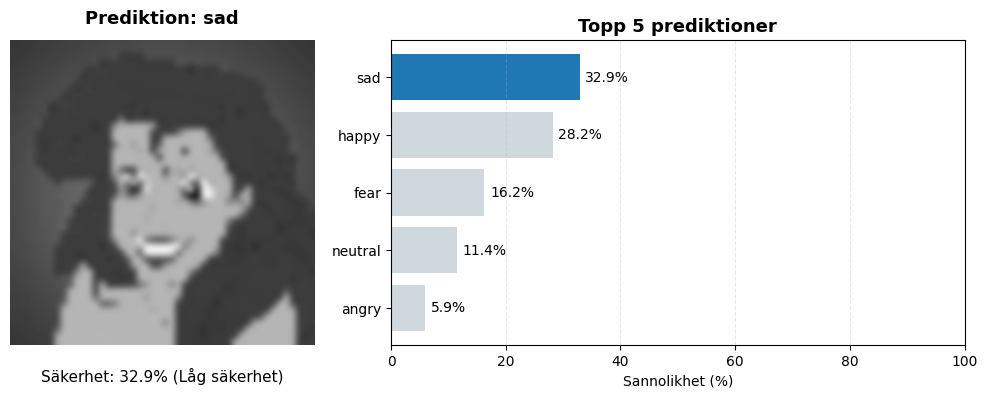

In [44]:
# Predicera en specifik bild från testdatasetet
index = 56
predict_test_image(
    image_index=index,
    X_test=X_test,
    y_test=y_test,
    model=loaded_model,
    class_names=class_names
)

# Predicera en helt egen, extern bild
image_path = 'Analys_bilder/ariel.jpg'
predict_custom_image(
    image_path=image_path,
    model=loaded_model,
    class_names=class_names
)

## 7. Analys av modellens resultat
De ligger ganska nära varandra (runt 53–54%), vilket visar att modellen har en god generaliseringsförmåga – den presterar nästan lika bra på helt osedd data som på den data den tränades på.

Min bästa modell (Improved 2 / Final) fick en **Test Accuracy på ca [Fyll i t.ex. 53.6%]** och en **Test Loss på [Fyll i t.ex. 1.2024]**. Eftersom datasetet har 7 klasser skulle en slumpmässig gissning bara ge 14 % rätt. Modellen har alltså absolut lärt sig att se skillnad på olika ansiktsuttryck, men resultatet varierar mycket mellan klasserna:

* **Styrkor:** Modellen är jättebra på `happy` (över 80 % rätt) och presterar även starkt på `surprise`.
* **Svagheter:** Modellen är nästan helt blind för den minsta klassen `disgust` (0 % rätt) och har stora problem med `fear`.

### Överfiskning och balans
Under projektets gång har jag tydligt sett hur olika val påverkar balansen i modellen:
* **Baseline-modellen** led av kraftig overfitting (överanpassning). Tränings-accuracy fortsatte att öka, men valideringsförlusten började stiga efter epok 6. Modellen memorerade bara träningsbilderna.
* **Lösningen** blev att lägga till **Dropout** och **Early Stopping**. Det dämpade överanpassningen i mina förbättrade modeller. Tränings- och testkurvorna följer nu varandra stabilt, vilket visar att modellen har en god **generaliseringsförmåga** och klarar helt ny data.

### Vad påverkade resultatet mest?
1. **Datamängden:** Att gå från de mindre subsetten till hela datasetet gav det absolut största hoppet i prestanda (från ca 34 % till över 53 % accuracy). Mer data gjorde störst skillnad.
2. **Klassobalansen:** Datasetet är väldigt ojämnt. `happy` har över 7 000 bilder medan `disgust` bara har 436. Modellen blir därför partisk; den får massor av träning på de stora klasserna men lär sig aldrig de små ordentligt.
3. **Regularisering:** Utan Dropout och Early Stopping overfittar modellen direkt.

### Modellens begränsningar
* **Låg upplösning (48x48 pixlar):** Detta är den största begränsningen. Bilderna är så små att viktiga detaljer, som små rynkningar mellan ögonbrynen vid sorg eller rädsla, blir till suddigt brus. Det förklarar också varför *Data Augmentation* (zoom och rotation) gjorde modellen sämre; förvrängningarna förstörde de få detaljer som faktiskt fanns.
* **Visuella förväxlingar:** Min Confusion Matrix visar att modellen ständigt blandar ihop känslor som liknar varandra rent visuellt, framför allt `sad` med `neutral` samt `fear` med `sad`. 
* **Mänsklig faktor:** Gränsen mellan att vara exempelvis "neutral" eller "ledsen" är flytande och subjektiv även för människor, vilket skapar ett naturligt brus i datans etiketter.

## 8. Självreflektion

### Utmaningar och lärdomar
Det svåraste i uppgiften var att hantera kombinationen av extrem klassobalans och väldigt lågupplösta bilder. Det var en utmaning att försöka hjälpa de mindre klasserna utan att förstöra för de stora. Jag tyckte också det var klurigt i början att förstå varför valideringskurvorna såg "för bra ut" när jag använde data augmentation, innan jag insåg att det berodde på att träningsdatan artificiellt gjorts svårare för modellen.

Jag har lärt mig att arbeta iterativt – att testa, utvärdera och backa tillbaka. Jag har fått en praktisk förståelse för hur Dropout och Early Stopping styr modellens inlärning, och insett att mer data ofta är viktigare än en komplex modell. Om jag hade gjort om uppgiften idag skulle jag ha fokuserat på klassobalansen direkt i starten, till exempel genom att kopiera upp bilderna i de mindre klasserna (*oversampling*) eller använda *class weights* i Keras för att straffa modellen hårdare när den gissar fel på minoritetsklasser.

### Betygsmotivering (VG)
Jag anser att mitt arbete uppfyller kraven för **Väl Godkänd (VG)**.

* **Jämfört modeller:** Jag har utvecklat och jämfört **fyra olika modellvarianter** (Baseline, Improved, Improved 2 och en Final modell med data augmentation) för att se hur olika val påverkar resultatet.
* **Förbättrat modellen:** Jag har laborerat aktivt med hyperparametrar som dropout-nivåer, epochs, patience och olika dataset-storlekar.
* **Djupare analys:** Jag har tolkat träningskurvorna i detalj och använt Confusion Matrix för att göra en konkret felanalys per klass.
* **Kritisk diskussion:** Jag har fört ett tydligt resonemang kring modellens begränsningar, effekten av klassobalans och hur bildernas låga upplösning (48x48) sätter stopp för djupare generalisering.

När man testar egna bilder blir det väldigt tydligt hur extremt mycket information som går förlorad vid $48 \times 48$ pixlar. Som synes på exempelbilden blir ansikten väldigt blockiga, och det är helt logiskt att modellen får kämpa med låg säkerhet (33.9 % på bilden) eftersom viktiga ansiktsdrag helt enkelt suddas ut vid nedskalningen